In [1]:
#Short version meant for testing. For better understanding read the temprature_predictor.ipynb

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import sklearn

In [3]:
weather = pd.read_csv("data/Thessaloniki_Weather.csv")
core_weather = weather[["DATE", "PRCP", "TMAX", "TMIN"]].copy()
core_weather.columns = ["date", "percip", "max_temp", "min_temp"]
core_weather = core_weather.set_index("date")

In [4]:
#We will deal with null values. 2 main tactics: 1. I put the last value of that column wherever null 2. I put zero
core_weather["percip"] = core_weather["percip"].fillna(0)
core_weather = core_weather.fillna(method="ffill")

In [5]:
#datetime more useful
core_weather.index = pd.to_datetime(core_weather.index)
#If x = 9999 then it means null
core_weather.apply(lambda x: (x==9999).sum())

percip      0
max_temp    0
min_temp    0
dtype: int64

In [6]:
#Duplicates in 1998, 1999, 2000, 2001, 2002, 2003, 2004   
core_weather = core_weather.reset_index()
core_weather = core_weather.drop_duplicates(subset=['date'])
core_weather = core_weather.set_index('date')

In [7]:
#Since we want to predict the next week, 7 targets are set to next 7 days of each day
core_weather["target1_max"] = core_weather.shift(-1)["max_temp"]
core_weather["target1_min"] = core_weather.shift(-1)["min_temp"]

core_weather["target2_max"] = core_weather.shift(-2)["max_temp"]
core_weather["target2_min"] = core_weather.shift(-2)["min_temp"]

core_weather["target3_max"] = core_weather.shift(-3)["max_temp"]
core_weather["target3_min"] = core_weather.shift(-3)["min_temp"]

core_weather["target4_max"] = core_weather.shift(-4)["max_temp"]
core_weather["target4_min"] = core_weather.shift(-4)["min_temp"]

core_weather["target5_max"] = core_weather.shift(-5)["max_temp"]
core_weather["target5_min"] = core_weather.shift(-5)["min_temp"]

core_weather["target6_max"] = core_weather.shift(-6)["max_temp"]
core_weather["target6_min"] = core_weather.shift(-6)["min_temp"]

core_weather["target7_max"] = core_weather.shift(-7)["max_temp"]
core_weather["target7_min"] = core_weather.shift(-7)["min_temp"]

core_weather = core_weather.iloc[:-7, :].copy()

In [8]:
core_weather["avg_max_month"] = core_weather["max_temp"].rolling(30).mean()
core_weather["avg_min_month"] = core_weather["min_temp"].rolling(30).mean()
core_weather = core_weather.iloc[30:, :].copy()

In [9]:
core_weather["daily_avg_offset_max"] = core_weather["avg_max_month"] / core_weather["max_temp"]
core_weather["daily_avg_offset_min"] = core_weather["avg_min_month"] / core_weather["min_temp"]

In [10]:
core_weather["max_min_ratio"] = core_weather["max_temp"] / core_weather["min_temp"]

In [11]:
#Infinity doesn't allow prediction
core_weather = core_weather.reset_index()

core_weather = core_weather.drop(core_weather[core_weather.daily_avg_offset_max == core_weather["daily_avg_offset_max"].max()].index)
core_weather = core_weather.drop(core_weather[core_weather.daily_avg_offset_max == core_weather["daily_avg_offset_max"].min()].index)

core_weather = core_weather.drop(core_weather[core_weather.daily_avg_offset_min == core_weather["daily_avg_offset_min"].max()].index)
core_weather = core_weather.drop(core_weather[core_weather.daily_avg_offset_min == core_weather["daily_avg_offset_min"].min()].index)

core_weather = core_weather.drop(core_weather[core_weather.max_min_ratio == core_weather["max_min_ratio"].max()].index)
core_weather = core_weather.drop(core_weather[core_weather.max_min_ratio == core_weather["max_min_ratio"].min()].index)

core_weather = core_weather.set_index('date')

In [12]:
#Ridge useful when independent variables are highly correlated 
from sklearn.linear_model import Ridge

#Minimizes ||y - Xw||^2_2 + alpha * ||w||^2_2
reg1_max = Ridge(alpha=.1)
reg1_min = Ridge(alpha=.1)

reg2_max = Ridge(alpha=.1)
reg2_min = Ridge(alpha=.1)

reg3_max = Ridge(alpha=.1)
reg3_min = Ridge(alpha=.1)

reg4_max = Ridge(alpha=.1)
reg4_min = Ridge(alpha=.1)

reg5_max = Ridge(alpha=.1)
reg5_min = Ridge(alpha=.1)

reg6_max = Ridge(alpha=.1)
reg6_min = Ridge(alpha=.1)

reg7_max = Ridge(alpha=.1)
reg7_min = Ridge(alpha=.1)

from sklearn.metrics import mean_absolute_error

In [13]:
#Automation1
def create_prediction_max (predictors, core_weather, reg1_max, reg2_max, reg3_max, reg4_max, reg5_max, reg6_max, reg7_max):
    train = core_weather.loc[:"2021-12-31"]
    test = core_weather.loc["2022-01-01":]

    reg1_max.fit(train[predictors], train["target1_max"])
    predictions1_max = reg1_max.predict(test[predictors])
    error1_max = mean_absolute_error(test["target1_max"], predictions1_max)
    score1_max = reg1_max.score(test[predictors], test["target1_max"])
    combined1_max = pd.concat([test["target1_max"], pd.Series(predictions1_max, index=test.index)] ,axis=1)
    combined1_max.columns = ["actual1_max", "predictions1_max"]

    reg2_max.fit(train[predictors], train["target2_max"])
    predictions2_max = reg2_max.predict(test[predictors])
    error2_max = mean_absolute_error(test["target2_max"], predictions2_max)
    score2_max = reg2_max.score(test[predictors], test["target2_max"])
    combined2_max = pd.concat([test["target2_max"], pd.Series(predictions2_max, index=test.index)] ,axis=1)
    combined2_max.columns = ["actual2_max", "predictions2_max"]

    reg3_max.fit(train[predictors], train["target3_max"])
    predictions3_max = reg3_max.predict(test[predictors])
    error3_max = mean_absolute_error(test["target3_max"], predictions3_max)
    score3_max = reg3_max.score(test[predictors], test["target3_max"])
    combined3_max = pd.concat([test["target3_max"], pd.Series(predictions3_max, index=test.index)] ,axis=1)
    combined3_max.columns = ["actual3_max", "predictions3_max"]

    reg4_max.fit(train[predictors], train["target4_max"])
    predictions4_max = reg4_max.predict(test[predictors])
    error4_max = mean_absolute_error(test["target4_max"], predictions4_max)
    score4_max = reg4_max.score(test[predictors], test["target4_max"])
    combined4_max = pd.concat([test["target4_max"], pd.Series(predictions4_max, index=test.index)] ,axis=1)
    combined4_max.columns = ["actual4_max", "predictions4_max"]

    reg5_max.fit(train[predictors], train["target5_max"])
    predictions5_max = reg5_max.predict(test[predictors])
    error5_max = mean_absolute_error(test["target5_max"], predictions5_max)
    score5_max = reg5_max.score(test[predictors], test["target5_max"])
    combined5_max = pd.concat([test["target5_max"], pd.Series(predictions5_max, index=test.index)] ,axis=1)
    combined5_max.columns = ["actual5_max", "predictions5_max"]

    reg6_max.fit(train[predictors], train["target6_max"])
    predictions6_max = reg6_max.predict(test[predictors])
    error6_max = mean_absolute_error(test["target6_max"], predictions6_max)
    score6_max = reg6_max.score(test[predictors], test["target6_max"])
    combined6_max = pd.concat([test["target6_max"], pd.Series(predictions6_max, index=test.index)] ,axis=1)
    combined6_max.columns = ["actual6_max", "predictions6_max"]

    reg7_max.fit(train[predictors], train["target7_max"])
    predictions7_max = reg7_max.predict(test[predictors])
    error7_max = mean_absolute_error(test["target7_max"], predictions7_max)
    score7_max = reg7_max.score(test[predictors], test["target7_max"])
    combined7_max = pd.concat([test["target7_max"], pd.Series(predictions7_max, index=test.index)] ,axis=1)
    combined7_max.columns = ["actual7_max", "predictions7_max"]


    return error1_max, score1_max, combined1_max, error2_max, score2_max, combined2_max, error3_max, score3_max, combined3_max, error4_max, score4_max, combined4_max, error5_max, score5_max, combined5_max, error6_max, score6_max, combined6_max, error7_max, score7_max, combined7_max

In [14]:
#Automation2
def create_prediction_min (predictors, core_weather, reg1_min, reg2_min, reg3_min, reg4_min, reg5_min, reg6_min, reg7_min):
    train = core_weather.loc[:"2021-12-31"]
    test = core_weather.loc["2022-01-01":]

    reg1_min.fit(train[predictors], train["target1_min"])
    predictions1_min = reg1_min.predict(test[predictors])
    error1_min = mean_absolute_error(test["target1_min"], predictions1_min)
    score1_min = reg1_min.score(test[predictors], test["target1_min"])
    combined1_min = pd.concat([test["target1_min"], pd.Series(predictions1_min, index=test.index)] ,axis=1)
    combined1_min.columns = ["actual1_min", "predictions1_min"]

    reg2_min.fit(train[predictors], train["target2_min"])
    predictions2_min = reg2_min.predict(test[predictors])
    error2_min = mean_absolute_error(test["target2_min"], predictions2_min)
    score2_min = reg2_min.score(test[predictors], test["target2_min"])
    combined2_min = pd.concat([test["target2_min"], pd.Series(predictions2_min, index=test.index)] ,axis=1)
    combined2_min.columns = ["actual2_min", "predictions2_min"]

    reg3_min.fit(train[predictors], train["target3_min"])
    predictions3_min = reg3_min.predict(test[predictors])
    error3_min = mean_absolute_error(test["target3_min"], predictions3_min)
    score3_min = reg3_min.score(test[predictors], test["target3_min"])
    combined3_min = pd.concat([test["target3_min"], pd.Series(predictions3_min, index=test.index)] ,axis=1)
    combined3_min.columns = ["actual3_min", "predictions3_min"]

    reg4_min.fit(train[predictors], train["target4_min"])
    predictions4_min = reg4_min.predict(test[predictors])
    error4_min = mean_absolute_error(test["target4_min"], predictions4_min)
    score4_min = reg4_min.score(test[predictors], test["target4_min"])
    combined4_min = pd.concat([test["target4_min"], pd.Series(predictions4_min, index=test.index)] ,axis=1)
    combined4_min.columns = ["actual4_min", "predictions4_min"]

    reg5_min.fit(train[predictors], train["target5_min"])
    predictions5_min = reg5_min.predict(test[predictors])
    error5_min = mean_absolute_error(test["target5_min"], predictions5_min)
    score5_min = reg5_min.score(test[predictors], test["target5_min"])
    combined5_min = pd.concat([test["target5_min"], pd.Series(predictions5_min, index=test.index)] ,axis=1)
    combined5_min.columns = ["actual5_min", "predictions5_min"]

    reg6_min.fit(train[predictors], train["target6_min"])
    predictions6_min = reg6_min.predict(test[predictors])
    error6_min = mean_absolute_error(test["target6_min"], predictions6_min)
    score6_min = reg6_min.score(test[predictors], test["target6_min"])
    combined6_min = pd.concat([test["target6_min"], pd.Series(predictions6_min, index=test.index)] ,axis=1)
    combined6_min.columns = ["actual6_min", "predictions6_min"]

    reg7_min.fit(train[predictors], train["target7_min"])
    predictions7_min = reg7_min.predict(test[predictors])
    error7_min = mean_absolute_error(test["target7_min"], predictions7_min)
    score7_min = reg7_min.score(test[predictors], test["target7_min"])
    combined7_min = pd.concat([test["target7_min"], pd.Series(predictions7_min, index=test.index)] ,axis=1)
    combined7_min.columns = ["actual7_min", "predictions7_min"]

    return error1_min, score1_min, combined1_min, error2_min, score2_min, combined2_min, error3_min, score3_min, combined3_min, error4_min, score4_min, combined4_min, error5_min, score5_min, combined5_min, error6_min, score6_min, combined6_min, error7_min, score7_min, combined7_min 

In [15]:
#Better results with these predictors
predictors = ["percip", "max_temp", "min_temp", "avg_max_month", "daily_avg_offset_max"]
error1_max, score1_max, combined1_max, error2_max, score2_max, combined2_max, error3_max, score3_max, combined3_max, error4_max, score4_max, combined4_max, error5_max, score5_max, combined5_max, error6_max, score6_max, combined6_max, error7_max, score7_max, combined7_max =create_prediction_max (predictors, core_weather, reg1_max, reg2_max, reg3_max, reg4_max, reg5_max, reg6_max, reg7_max)

In [16]:
#Better results with these predictors
predictors = ["percip", "max_temp", "min_temp", "avg_max_month", "daily_avg_offset_max"]
error1_min, score1_min, combined1_min, error2_min, score2_min, combined2_min, error3_min, score3_min, combined3_min, error4_min, score4_min, combined4_min, error5_min, score5_min, combined5_min, error6_min, score6_min, combined6_min, error7_min, score7_min, combined7_min =create_prediction_min (predictors, core_weather, reg1_min, reg2_min, reg3_min, reg4_min, reg5_min, reg6_min, reg7_min)

<Axes: xlabel='date'>

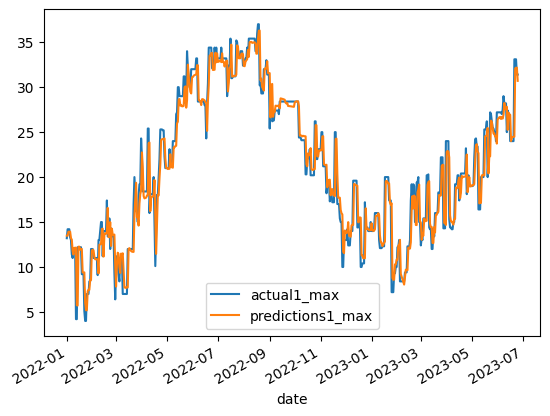

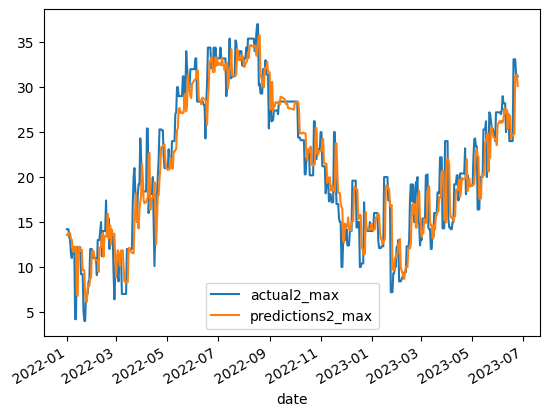

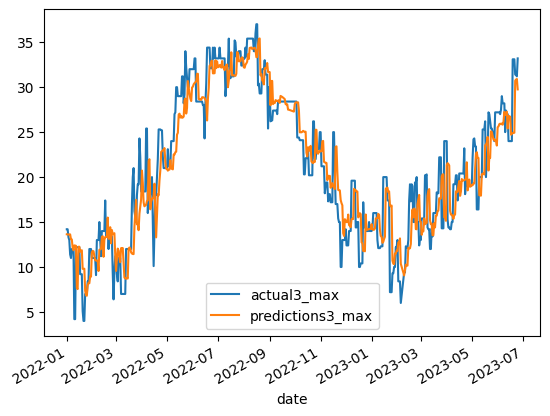

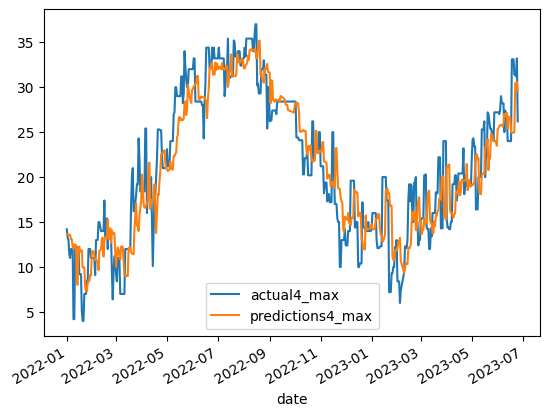

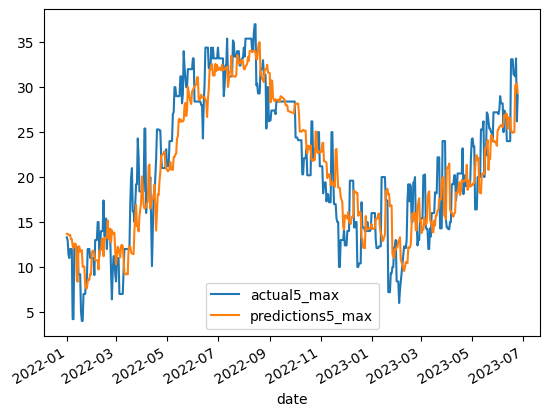

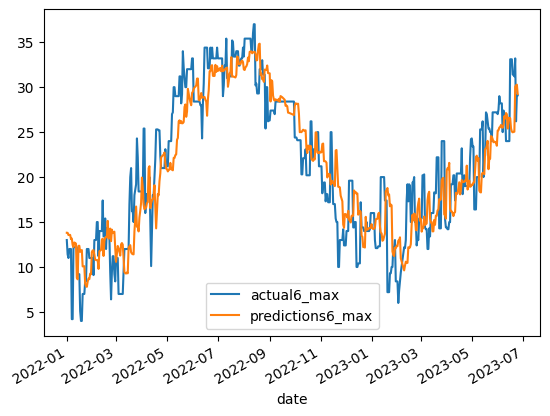

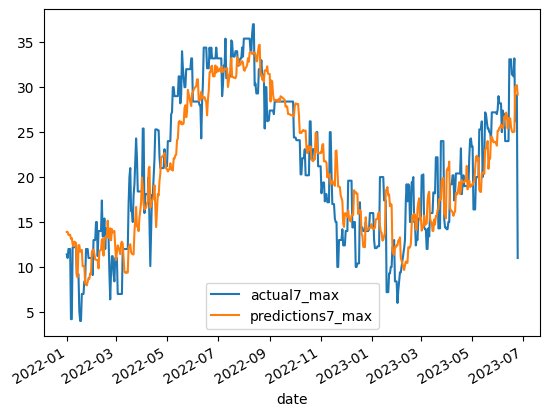

In [17]:
combined1_max.plot()
combined2_max.plot()
combined3_max.plot()
combined4_max.plot()
combined5_max.plot()
combined6_max.plot()
combined7_max.plot()

In [18]:
#Duplicates in 1998, 1999, 2000, 2001, 2002, 2003, 2004   
core_weather = core_weather.reset_index()
core_weather = core_weather.drop_duplicates(subset=['date'])
core_weather = core_weather.set_index('date')
core_weather

,percip,max_temp,min_temp,target1_max,target1_min,target2_max,target2_min,target3_max,target3_min,target4_max,...,target5_min,target6_max,target6_min,target7_max,target7_min,avg_max_month,avg_min_month,daily_avg_offset_max,daily_avg_offset_min,max_min_ratio
date,,,,,,,,,,,,,,,,,,,,,
1964-02-13,0.0,15.0,-2.8,15.0,-2.8,12.2,3.9,12.2,7.2,15.0,...,2.8,17.2,2.8,7.8,2.2,8.720000,-3.606667,0.581333,1.288095,-5.357143
1964-02-14,0.0,15.0,-2.8,12.2,3.9,12.2,7.2,15.0,1.1,17.2,...,2.8,7.8,2.2,7.2,-2.2,9.016667,-3.606667,0.601111,1.288095,-5.357143
1964-02-15,0.0,12.2,3.9,12.2,7.2,15.0,1.1,17.2,2.8,17.2,...,2.2,7.2,-2.2,10.0,1.1,9.163333,-3.310000,0.751093,-0.848718,3.128205
1964-02-16,0.0,12.2,7.2,15.0,1.1,17.2,2.8,17.2,2.8,7.8,...,-2.2,10.0,1.1,10.0,5.0,9.330000,-3.033333,0.764754,-0.421296,1.694444
1964-02-17,0.0,15.0,1.1,17.2,2.8,17.2,2.8,7.8,2.2,7.2,...,1.1,10.0,5.0,12.8,1.1,9.496667,-2.830000,0.633111,-2.572727,13.636364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-06-21,0.0,24.0,17.6,33.1,20.0,33.1,20.8,33.1,20.8,31.4,...,18.7,31.2,20.0,33.2,20.0,26.176667,15.776667,1.090694,0.896402,1.363636
2023-06-22,0.0,33.1,20.0,33.1,20.8,33.1,20.8,31.4,18.7,31.4,...,20.0,33.2,20.0,26.2,20.0,26.533333,15.976667,0.801611,0.798833,1.655000
2023-06-23,0.0,33.1,20.8,33.1,20.8,31.4,18.7,31.4,18.7,31.2,...,20.0,26.2,20.0,29.1,20.0,26.730000,16.203333,0.807553,0.779006,1.591346


1.3263995391499483

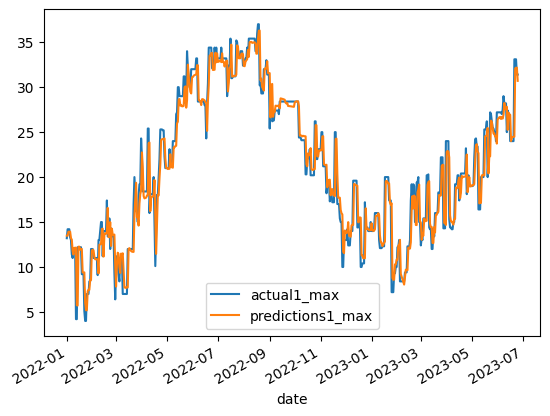

In [19]:
combined1_max.plot()
error1_max

1.2640310839939795

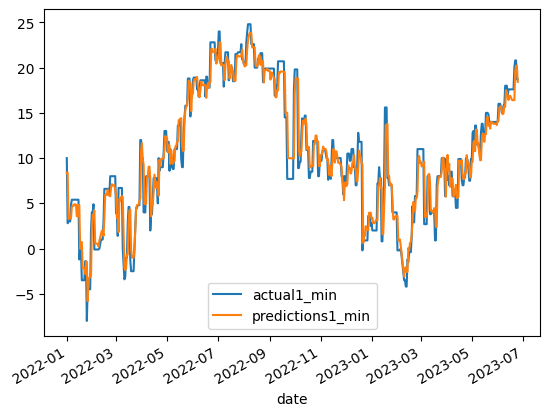

In [20]:
combined1_min.plot()
error1_min

2.018731936493259

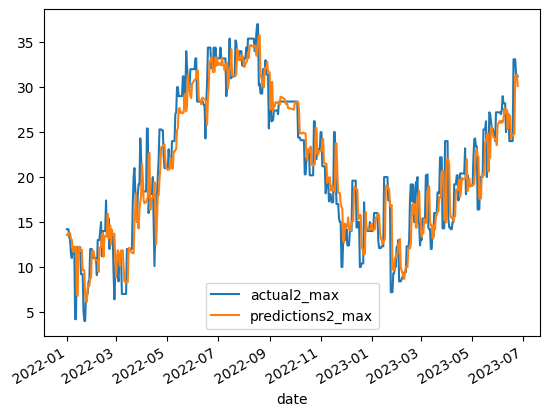

In [21]:
combined2_max.plot()
error2_max

1.8607201709049508

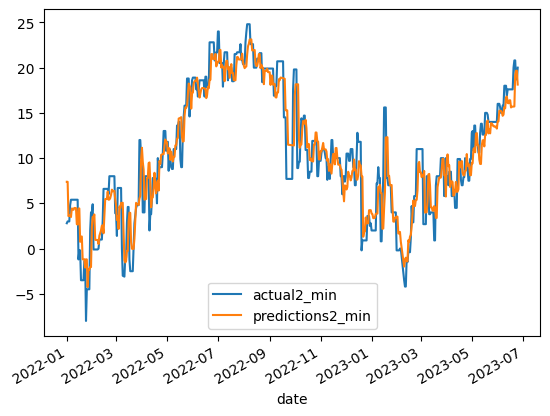

In [22]:
combined2_min.plot()
error2_min